# HANDS-ON: two houses that do not fit

In the pairplot in `1a` almost every house follows the same rule - larger area,
higher price. Two houses break it: very large, and cheap.

Your assignment is to find out why, using the data rather than a guess, and to
decide what to do with them.

There is an answer in this dataset and it can be found in the time available.

## Part 0 - Setup

Run this cell first, in every notebook. It fetches the course repository into
the Colab session and moves into the `notebooks/` folder, so that the
`../data/...` paths work.

It is safe to run more than once, and safe after a restart.

Note: outside Colab the cell does nothing except report the working directory.
Start Jupyter from inside `notebooks/` and the paths work the same way.

If it prints `data ok: True`, you are set.

In [1]:
# --- SETUP: run this first ---  [lares-setup-v1]
# works in Colab and locally, safe to run more than once
import os, sys, subprocess
REPO = "ai_bootcamp_foundations"
if "google.colab" in sys.modules:
    if not os.path.isdir(f"/content/{REPO}"):
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/unizg-fer-lares/{REPO}.git"],
                       cwd="/content", check=True)
    os.chdir(f"/content/{REPO}/notebooks")
print("cwd:", os.getcwd(), "| data ok:", os.path.isdir("../data"))

cwd: C:\Users\novak\Desktop\files\notebooks | data ok: True


## Part 1 - Load the dataset

We load the raw dataset rather than the cleaned one from `1a`, because the two
houses are still in it.

In [2]:
import numpy as np, pandas as pd

# same plot styling as in 1a
import seaborn as sns
sns.set_theme(style="whitegrid")
import matplotlib.pyplot as plt
tex_fonts = {
    "font.family": "serif",
    # Use 26pt font in plots
    "axes.labelsize": 20,
    "font.size": 20,
    "figure.titlesize": 20,
    # Make the legend/label fonts a little smaller
    "legend.title_fontsize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18
}

plt.rcParams.update(tex_fonts)

In [3]:
df = pd.read_csv("../data/housing_prices/housing.csv", index_col="Id")
print('Size of dataset', df.shape)

# helper for looking up what a column means
def describe_field(name, path='../data/housing_prices/data_description.txt'):
    lines = open(path, encoding='latin-1').read().splitlines()
    out, on = [], False
    for line in lines:
        if line.startswith(name + ':'):
            on = True
        elif on and line and not line[0].isspace():
            break
        if on:
            out.append(line.rstrip())
    print('\n'.join(out) if out else "'%s' not found" % name)

Size of dataset (1460, 80)


## Part 2 - The plot

`GrLivArea` against `SalePrice`, with the two houses marked.

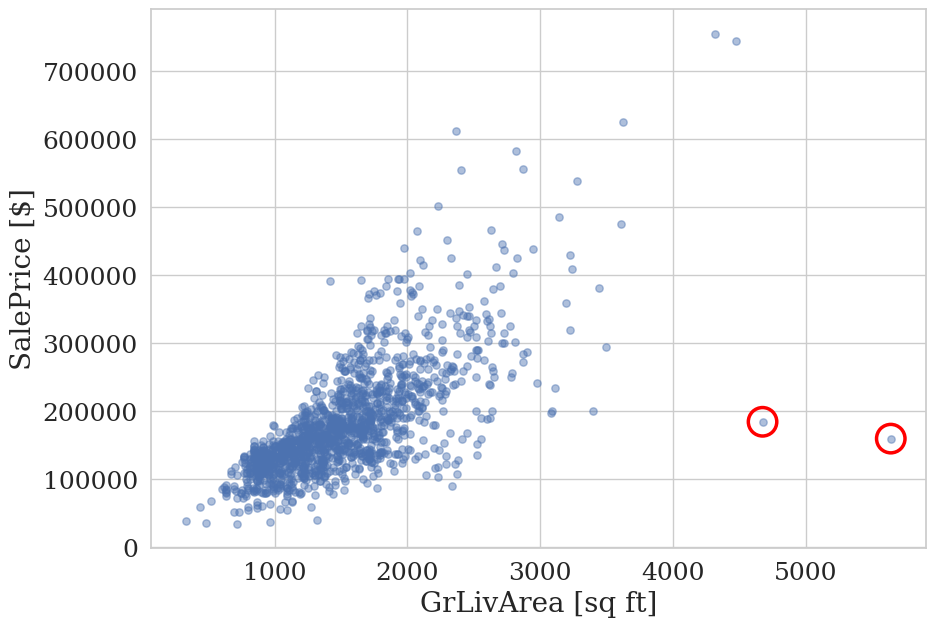

In [4]:
# the two cheapest houses per square foot among the largest ones
marked = (df['SalePrice'] / df['GrLivArea'])[df['GrLivArea'] > 3500].nsmallest(2)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(df['GrLivArea'], df['SalePrice'], s=28, alpha=0.45)
ax.scatter(df.loc[marked.index, 'GrLivArea'], df.loc[marked.index, 'SalePrice'],
           s=420, facecolors='none', edgecolors='red', linewidths=2.5)

ax.set_xlabel('GrLivArea [sq ft]')
ax.set_ylabel('SalePrice [$]')
plt.show()

## Part 3 - The assignment

Answer three questions, in order:

1. what is unusual about these two houses,
2. why are they cheap,
3. do you remove them from the dataset or keep them.

Write the answer in the markdown cell at the end. Two or three sentences are
enough - the answers are compared together afterwards.

Your task can be divided into the following steps:
- filter the two circled houses out of the dataset - two conditions are enough - and look at all of their features,
- compare them against a reference: the whole dataset, and their closest peers,
- find the column that separates them from those peers,
- check whether that column explains the price on its own.

Note: `../data/housing_prices/data_description.txt` describes every column in
the dataset. It is the most useful file in the folder and the one most often
skipped.

### Two ways to work

**Group 1** - write pandas in the cell below.

**Group 2** - run the helper cells instead. They name the two houses, print all
of their features, and look up what each column means. All three questions can be
answered by reading, and the answer is the same one. Ask if anything is
unclear, that is what the slot is for.

### Hints

Open them only when stuck.

<details>
<summary>Hint 1 - isolating them</summary>

Two conditions on two columns, combined with `&`, and each condition in its own
brackets. Read the axes of the plot to pick the thresholds.

```python
odd = df[(df['GrLivArea'] > ...) & (df['SalePrice'] < ...)]
odd.T          # transposed, one column per house
```

Then look for what is *different* about them, not only for what is large.
</details>

<details>
<summary>Hint 2 - what to compare against</summary>

"Cheap" only means something relative to a reference. Two useful ones:
- price per square foot, `df['SalePrice'] / df['GrLivArea']`, against the median of the dataset,
- their peers - other houses with `GrLivArea > 4000`, or with `OverallQual == 10`. There are only a few of each.
</details>

<details>
<summary>Hint 3 - where to look</summary>

The correlation ranking in `1a` used `numeric_only=True`. The dataset has 43
categorical columns and none of them appeared in that ranking.

Two of those columns describe the sale rather than the house.
</details>

<details>
<summary>Hint 4 - the trap</summary>

If you found a category the two houses share, check whether that category is
cheap in general. Group the dataset by it and compare medians.
</details>

In [5]:
# GROUP 1 - your workspace
# suggested start:
#   odd = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
#   odd.T



In [6]:
# GROUP 2 - all features of the two houses
odd = df.loc[[524, 1299]]

pd.set_option('display.max_rows', 100)
odd.T

Id,524,1299
MSSubClass,60,60
MSZoning,RL,RL
LotFrontage,130.0,313.0
LotArea,40094,63887
Street,Pave,Pave
Alley,NaN,NaN
LotShape,IR1,IR3
LandContour,Bnk,Bnk
Utilities,AllPub,AllPub
LotConfig,Inside,Corner


In [7]:
# GROUP 2 - look up what a column means, e.g.
describe_field('SaleCondition')

SaleCondition: Condition of sale

       Normal	Normal Sale
       Abnorml	Abnormal Sale -  trade, foreclosure, short sale
       AdjLand	Adjoining Land Purchase
       Alloca	Allocation - two linked properties with separate deeds, typically condo with a garage unit
       Family	Sale between family members
       Partial	Home was not completed when last assessed (associated with New Homes)


### Comparisons

Group 2: the numbers Group 1 would compute. Read them and answer the three
questions.

In [8]:
df2 = df.copy()
df2['PricePerSqFt'] = df2['SalePrice'] / df2['GrLivArea']

print('price per sq ft, dataset median: %.1f' % df2['PricePerSqFt'].median())
print('price per sq ft, the two houses:',
      ', '.join('%.1f' % v for v in df2.loc[marked.index, 'PricePerSqFt']))

print('\nevery house above 4000 sq ft:')
big = df2[df2['GrLivArea'] > 4000]
print(big[['GrLivArea', 'SalePrice', 'OverallQual', 'Neighborhood',
           'SaleCondition', 'PricePerSqFt']].round(1).to_string())

price per sq ft, dataset median: 120.1
price per sq ft, the two houses: 28.4, 39.5

every house above 4000 sq ft:
      GrLivArea  SalePrice  OverallQual Neighborhood SaleCondition  PricePerSqFt
Id                                                                              
524        4676     184750           10      Edwards       Partial          39.5
692        4316     755000           10      NoRidge        Normal         174.9
1183       4476     745000           10      NoRidge       Abnorml         166.4
1299       5642     160000           10      Edwards       Partial          28.4


---

## Solution

Below this point are the answers. The exercise is worth more than reading them.

---

### Step 1 - what is unusual

`Id 524` and `Id 1299`. Both are large, new, graded `OverallQual == 10`, and
sold for less than a third of what comparable houses did.

In [9]:
odd = df.loc[[524, 1299]]

cols = ['GrLivArea', 'SalePrice', 'OverallQual', 'YearBuilt',
        'SaleType', 'SaleCondition', 'Neighborhood', 'LotArea']
print(odd[cols].T.to_string())

print('\nprice per sq ft:')
for house_id in odd.index:
    print('  Id %d: %5.1f' % (house_id,
          df.loc[house_id, 'SalePrice'] / df.loc[house_id, 'GrLivArea']))
print('  dataset median: %.1f' % (df['SalePrice'] / df['GrLivArea']).median())

Id                524      1299
GrLivArea         4676     5642
SalePrice       184750   160000
OverallQual         10       10
YearBuilt         2007     2008
SaleType           New      New
SaleCondition  Partial  Partial
Neighborhood   Edwards  Edwards
LotArea          40094    63887

price per sq ft:
  Id 524:  39.5
  Id 1299:  28.4
  dataset median: 120.1


### Step 2 - the column that explains it

`SaleCondition == 'Partial'` and `SaleType == 'New'`. From
`data_description.txt`:

> Partial - Home was not completed when last assessed (associated with New Homes)

The recorded price is not the price of a finished house.

Neither column appears in the correlation ranking from `1a`, because that
ranking covered numeric columns only.

In [10]:
describe_field('SaleCondition')

SaleCondition: Condition of sale

       Normal	Normal Sale
       Abnorml	Abnormal Sale -  trade, foreclosure, short sale
       AdjLand	Adjoining Land Purchase
       Alloca	Allocation - two linked properties with separate deeds, typically condo with a garage unit
       Family	Sale between family members
       Partial	Home was not completed when last assessed (associated with New Homes)


### Step 3 - the trap

`Partial` alone does not explain a low price. Partial sales are the most
expensive group in the dataset. Only 2 of 125 of them are anywhere near this
cheap - these two.

In [11]:
# is 'Partial' cheap in general?
grouped = df.groupby('SaleCondition').agg(count=('SalePrice', 'size'),
                                          median_price=('SalePrice', 'median'),
                                          median_area=('GrLivArea', 'median'),
                                          median_quality=('OverallQual', 'median'))
print(grouped.sort_values('count', ascending=False).round(0).to_string())

partial = df[df['SaleCondition'] == 'Partial'].copy()
partial['ppsf'] = partial['SalePrice'] / partial['GrLivArea']
print('\npartial sales below 50 $/sq ft: %d of %d' %
      ((partial['ppsf'] < 50).sum(), len(partial)))
print('  ', partial[partial['ppsf'] < 50].index.tolist())

               count  median_price  median_area  median_quality
SaleCondition                                                  
Normal          1198      160000.0       1456.0             6.0
Partial          125      244600.0       1646.0             7.0
Abnorml          101      130000.0       1302.0             5.0
Family            20      140500.0       1390.0             6.0
Alloca            12      148145.0       1440.0             5.0
AdjLand            4      104000.0       1143.0             5.0

partial sales below 50 $/sq ft: 2 of 125
   [524, 1299]


### Step 4 - the second half of the explanation

The other very large, top-quality houses are in `NoRidge` and sold for around
750 000 $. These two are in `Edwards`, where the median price per square foot
is about 100 $ against 128 $ in NoRidge.

Together: very large, top-grade, unfinished houses in a neighbourhood that does
not support those prices.

In [12]:
q10 = df[df['OverallQual'] == 10].copy()
q10['ppsf'] = q10['SalePrice'] / q10['GrLivArea']
q10['where'] = np.where(q10['Neighborhood'] == 'Edwards', 'Edwards', 'elsewhere')

print(q10.groupby('where')[['SalePrice', 'GrLivArea', 'ppsf']]
         .agg(['size', 'median']).round(1).to_string())

          SalePrice           GrLivArea         ppsf       
               size    median      size  median size median
where                                                      
Edwards           2  172375.0         2  5159.0    2   33.9
elsewhere        16  445365.0        16  2397.0   16  176.1


### Step 5 - remove them or keep them

Arguments for removing:
- they are not comparable to anything else in the dataset,
- they sit far out on the x axis, which gives them large leverage on a linear model,
- most published analyses of this dataset drop them.

Arguments for keeping:
- they are not errors, they are a documented category with 125 members,
- removing the two extreme ones hides the fact that the category was never handled,
- a model trained this way has nothing sensible to say about an unfinished house.

A third option is to keep them and add `SaleCondition` as a feature, so that the
model can learn that partial sales behave differently.

The cell below measures all three on the baseline from `1b`.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

feats = ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt']
work = df[feats + ['SalePrice', 'SaleCondition']].dropna()


def score(X, y, label):
    r2 = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2').mean()
    print('%-44s R2 = %.3f' % (label, r2))


score(work[feats], work['SalePrice'], 'keep everything, no SaleCondition')

kept = work.drop(index=[i for i in odd.index if i in work.index])
score(kept[feats], kept['SalePrice'], 'remove the two houses')

enc = pd.get_dummies(work['SaleCondition'], prefix='sale', drop_first=True)
score(pd.concat([work[feats], enc], axis=1), work['SalePrice'],
      'keep them, add SaleCondition')

keep everything, no SaleCondition            R2 = 0.759
remove the two houses                        R2 = 0.806
keep them, add SaleCondition                 R2 = 0.761


### Reading that result

Removing the two houses gives the best score, and adding `SaleCondition`
changes almost nothing. That is not the convenient answer, and it has three
causes worth naming:

- a linear model cannot express "this group follows a different price curve" - a one-hot column shifts the intercept, not the slope, so the leverage stays,
- the metric is an average over a test split in which partial sales are rare, so removing the two hardest cases improves the average by construction,
- a tree-based model can split on `SaleCondition` and then fit a different relationship, which is day 3.

So the decision depends on the model and on what the model is for. An
improvement in R2 is not on its own evidence that a decision was correct.

If the deliverable is a score on similar data, remove them. If the deliverable
is a system that prices real houses, removing the only two examples of a
failure mode is how a confident wrong answer is produced later.

### Your answer

<!-- write two or three sentences here -->

**Answer:**


### Conclusions - overall:
- *an outlier is a question, not a defect - "remove beyond 3 sigma" is a procedure, not an analysis,*
- *the column that explained the largest anomalies in the dataset was categorical and never entered the correlation ranking,*
- *a group median can point the opposite way to an individual case - partial sales are the most expensive group and contain the two cheapest houses per square foot,*
- *`data_description.txt` gave the answer in one line,*
- *removing rows is a modelling decision, not cleaning - record it with the reason, or the row count will not add up in three months.*


_University of Zagreb Faculty of Electrical Engineering and Computing_  
_Laboratory for Renewable Energy Systems_  

_Course: AI bootcamp - Foundations of AI_  
_Notebook: 1c_Hands_on_two_houses_  

_Website: [www.lares.fer.hr](https://www.lares.fer.hr/)_  
_Contact: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_
